<a href="https://colab.research.google.com/github/tresap12/mjc.ai.ml/blob/main/QR_Phishing_RF_Train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 QR 피싱 URL 탐지 — 랜덤포레스트 모델 학습
**URL Classification 데이터셋**을 사용해 랜덤포레스트 모델을 학습하고,
`rf_model.pkl` 파일을 다운로드해 프로젝트에 바로 적용할 수 있습니다.

---
### 📋 실행 순서
1. **0단계** — 라이브러리 설치
2. **1단계** — 데이터셋 업로드
3. **2단계** — 데이터 탐색 & 전처리
4. **3단계** — 피처 추출
5. **4단계** — 모델 학습 & 평가
6. **5단계** — 모델 저장 & 다운로드

## 0단계. 라이브러리 설치

In [12]:
!pip install scikit-learn pandas numpy matplotlib seaborn joblib -q
print('✅ 설치 완료')

✅ 설치 완료


## 1단계. 데이터셋 업로드
> `URL Classification.csv` 파일을 업로드하세요.

In [13]:
from google.colab import files
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f'업로드된 파일: {CSV_PATH}')

Saving URL Classification.csv to URL Classification (1).csv
업로드된 파일: URL Classification (1).csv


## 2단계. 데이터 탐색 & 전처리

전체 데이터 크기: (1562977, 3)

카테고리 분포:
category
Arts          253840
Society       243943
Business      240177
Computers     117962
Science       110286
Recreation    106586
Sports        101328
Shopping       95270
Health         60097
Reference      58247
Games          56477
Kids           46182
Adult          35324
Home           28269
News            8989
Name: count, dtype: int64


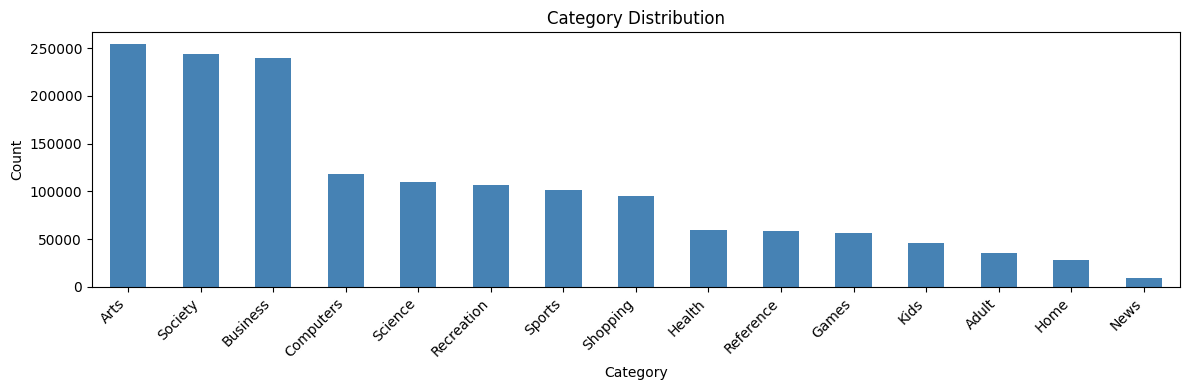

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

df = pd.read_csv(CSV_PATH, header=0)
df.columns = ['index', 'url', 'category']
print('전체 데이터 크기:', df.shape)
print()
print('카테고리 분포:')
print(df['category'].value_counts())

# 시각화
df['category'].value_counts().plot(kind='bar', figsize=(12,4), color='steelblue')
plt.title('Category Distribution')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

In [15]:
# 레이블 생성
# Adult / Shopping / Games → 위험(1), 나머지 → 안전(0)
RISKY = {'Adult', 'Shopping', 'Games'}
df['label'] = df['category'].apply(lambda c: 1 if c in RISKY else 0)

print('레이블 분포:')
print(df['label'].value_counts())
print(f"위험 비율: {df['label'].mean()*100:.1f}%")

# 클래스 불균형 해소 — 각 클래스 최대 100,000개 샘플링
SAMPLE_SIZE = 100_000
pos = df[df['label']==1].sample(min(SAMPLE_SIZE, df['label'].sum()), random_state=42)
neg = df[df['label']==0].sample(SAMPLE_SIZE, random_state=42)
sample = pd.concat([pos, neg]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f'\n균형 샘플 크기: {len(sample):,} (안전 {len(neg):,} / 위험 {len(pos):,})')

레이블 분포:
label
0    1375906
1     187071
Name: count, dtype: int64
위험 비율: 12.0%

균형 샘플 크기: 200,000 (안전 100,000 / 위험 100,000)


## 3단계. 피처 추출 (20개 피처)

In [16]:
import re
from urllib.parse import urlparse

SUSPICIOUS_KEYWORDS = [
    'login','verify','bank','secure','account','update',
    'confirm','apk','paypal','signin','password','free','click','win'
]
SUSPICIOUS_TLDS = ['.xyz','.top','.click','.shop','.info','.biz']
_IP = re.compile(r'^\d{1,3}(\.\d{1,3}){3}$')

def extract_features(url: str) -> dict:
    try:
        p = urlparse(url)
        domain = p.netloc.lower()
        path   = p.path.lower()
        dc     = sum(c.isdigit() for c in domain)
        return {
            'url_length':             len(url),
            'domain_length':          len(domain),
            'path_length':            len(path),
            'num_dots':               url.count('.'),
            'num_hyphens':            url.count('-'),
            'num_at':                 int('@' in url),
            'num_slash':              url.count('/'),
            'num_question':           url.count('?'),
            'num_equal':              url.count('='),
            'num_underscore':         url.count('_'),
            'num_percent':            url.count('%'),
            'num_ampersand':          url.count('&'),
            'has_https':              int(p.scheme == 'https'),
            'has_ip':                 int(bool(_IP.match(domain))),
            'num_subdomains':         max(len(domain.split('.')) - 2, 0),
            'digit_ratio':            dc / len(domain) if domain else 0,
            'has_suspicious_keyword': int(any(kw in url.lower() for kw in SUSPICIOUS_KEYWORDS)),
            'has_suspicious_tld':     int(any(domain.endswith(t) for t in SUSPICIOUS_TLDS)),
            'domain_hyphen_count':    domain.count('-'),
            'has_double_slash':       int('//' in path),
        }
    except:
        return {k: 0 for k in [
            'url_length','domain_length','path_length','num_dots','num_hyphens',
            'num_at','num_slash','num_question','num_equal','num_underscore',
            'num_percent','num_ampersand','has_https','has_ip','num_subdomains',
            'digit_ratio','has_suspicious_keyword','has_suspicious_tld',
            'domain_hyphen_count','has_double_slash',
        ]}

print('피처 추출 중... (약 1~2분 소요)')
X = sample['url'].apply(lambda u: pd.Series(extract_features(u)))
y = sample['label']
print(f'✅ 완료: {X.shape[0]:,}개 샘플, {X.shape[1]}개 피처')
X.head(3)

피처 추출 중... (약 1~2분 소요)
✅ 완료: 200,000개 샘플, 20개 피처


,url_length,domain_length,path_length,num_dots,num_hyphens,num_at,num_slash,num_question,num_equal,num_underscore,num_percent,num_ampersand,has_https,has_ip,num_subdomains,digit_ratio,has_suspicious_keyword,has_suspicious_tld,domain_hyphen_count,has_double_slash
0,33.0,25.0,1.0,4.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,1.0,0.0
1,55.0,22.0,26.0,5.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0
2,47.0,9.0,31.0,2.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4단계. 모델 학습 & 평가

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import numpy as np
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'학습: {len(X_train):,}개 / 테스트: {len(X_test):,}개')

print('\n모델 학습 중...')
model = RandomForestClassifier(
    n_estimators=100, max_depth=15,
    random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
print('✅ 학습 완료')

학습: 160,000개 / 테스트: 40,000개

모델 학습 중...
✅ 학습 완료


=== 분류 성능 ===
              precision    recall  f1-score   support

       안전(0)       0.65      0.56      0.60     20000
       위험(1)       0.61      0.69      0.65     20000

    accuracy                           0.63     40000
   macro avg       0.63      0.63      0.63     40000
weighted avg       0.63      0.63      0.63     40000

ROC-AUC: 0.6847


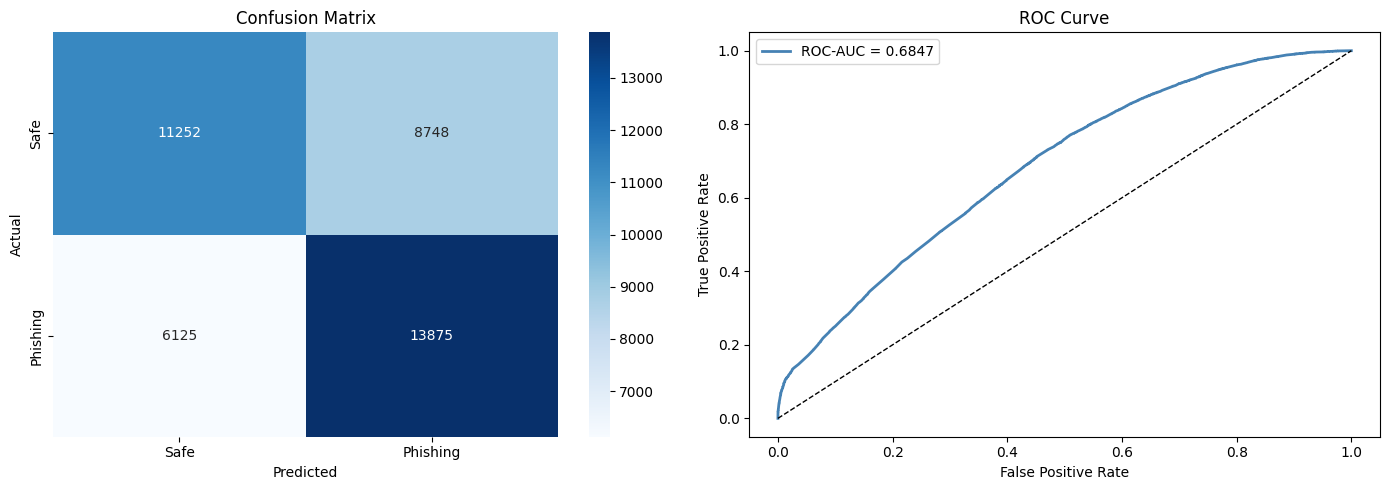

In [18]:
# 성능 평가
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('=== 분류 성능 ===')
print(classification_report(y_test, y_pred, target_names=['안전(0)', '위험(1)']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

# 혼동 행렬
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Safe','Phishing'], yticklabels=['Safe','Phishing'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC 곡선
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC-AUC = {roc_auc_score(y_test, y_proba):.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
plt.tight_layout(); plt.show()

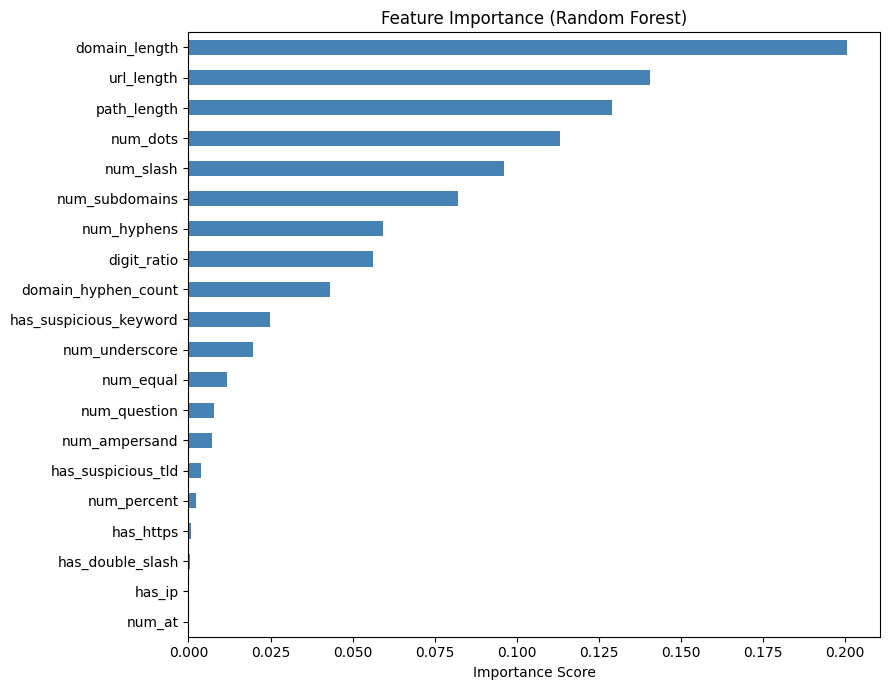


Top 10 중요 피처:
domain_length             0.200724
url_length                0.140608
path_length               0.129216
num_dots                  0.113260
num_slash                 0.096090
num_subdomains            0.082229
num_hyphens               0.059424
digit_ratio               0.056146
domain_hyphen_count       0.043069
has_suspicious_keyword    0.024785


In [19]:
# 피처 중요도 시각화
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', figsize=(9, 7), color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout(); plt.show()

print('\nTop 10 중요 피처:')
print(feat_imp.sort_values(ascending=False).head(10).to_string())

In [20]:
# 실제 URL 테스트
test_urls = [
    'https://www.naver.com/',
    'http://login-paypal.secure-update.xyz/verify/account',
    'http://192.168.1.1/bank/confirm',
    'https://www.google.com/search?q=python',
    'http://free-win-prize.click/update/apk',
]

print('=== 실시간 URL 예측 테스트 ===')
for url in test_urls:
    feat = pd.DataFrame([extract_features(url)])
    pred  = model.predict(feat)[0]
    proba = model.predict_proba(feat)[0][1]
    label = '🔴 위험' if pred else '🟢 안전'
    print(f'{label} ({proba*100:.1f}%) | {url}')

=== 실시간 URL 예측 테스트 ===
🔴 위험 (62.4%) | https://www.naver.com/
🔴 위험 (97.0%) | http://login-paypal.secure-update.xyz/verify/account
🟢 안전 (36.1%) | http://192.168.1.1/bank/confirm
🟢 안전 (38.9%) | https://www.google.com/search?q=python
🔴 위험 (94.5%) | http://free-win-prize.click/update/apk


## 5단계. 모델 저장 & 다운로드
> 다운로드된 `rf_model.pkl`을 `server/core/ml/models/` 폴더에 넣으세요.

In [21]:
import joblib
from google.colab import files

joblib.dump(model, 'rf_model.pkl')
print('✅ 모델 저장 완료: rf_model.pkl')

files.download('rf_model.pkl')
print('📥 다운로드 시작!')
print()
print('다운로드 후 → server/core/ml/models/rf_model.pkl 에 배치하세요.')

✅ 모델 저장 완료: rf_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 다운로드 시작!

다운로드 후 → server/core/ml/models/rf_model.pkl 에 배치하세요.


---
## ➕ 보너스: 하이퍼파라미터 튜닝 (선택)
> 더 좋은 성능을 원할 때 실행하세요. (시간 소요 큼)

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 15, 20],
    'min_samples_split': [2, 5],
}

# 시간 절약을 위해 학습 데이터 100%만 사용
X_sub = X_train.sample(frac=1.0, random_state=42)
y_sub = y_train.loc[X_sub.index]

gs = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='roc_auc', verbose=1
)
gs.fit(X_sub, y_sub)

print('최적 파라미터:', gs.best_params_)
print(f'Best ROC-AUC: {gs.best_score_:.4f}')

# 최적 파라미터로 전체 재학습
best_model = RandomForestClassifier(**gs.best_params_, random_state=42, n_jobs=-1)
best_model.fit(X_train, y_train)
y_pred2  = best_model.predict(X_test)
y_proba2 = best_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred2, target_names=['안전', '위험']))
print(f'ROC-AUC (튜닝 후): {roc_auc_score(y_test, y_proba2):.4f}')

# 튜닝된 모델 저장
joblib.dump(best_model, 'rf_model_tuned.pkl')
files.download('rf_model_tuned.pkl')
print('📥 튜닝 모델 다운로드 시작!')

Fitting 3 folds for each of 12 candidates, totalling 36 fits
최적 파라미터: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best ROC-AUC: 0.6889
              precision    recall  f1-score   support

          안전       0.66      0.56      0.61     20000
          위험       0.62      0.71      0.66     20000

    accuracy                           0.63     40000
   macro avg       0.64      0.63      0.63     40000
weighted avg       0.64      0.63      0.63     40000

ROC-AUC (튜닝 후): 0.6925


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 튜닝 모델 다운로드 시작!
